<a href="https://colab.research.google.com/github/vamsikrishnareddy2006/Internship-Tasks/blob/main/Day_9_Developer_Productivity_%26_Code_Quality_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/developer_productivity.csv")

df.head()

,developer_id,commits_per_week,lines_added,lines_deleted,files_changed,bugs_reported,code_review_comments,avg_review_time_hours,test_coverage_percent,deployment_frequency,late_night_commits,commit_risk
0,dev_07,8,89,54,1,3,0,4.5,67.0,2,1,Medium
1,dev_20,4,80,100,4,1,4,21.0,78.3,1,0,Medium
2,dev_08,9,18,9,9,0,4,4.9,79.9,3,0,Low
3,dev_15,3,33,107,4,0,1,15.9,82.5,2,3,Medium
4,dev_07,3,36,15,5,0,2,1.8,87.3,1,1,Low


In [2]:
df.columns

Index(['developer_id', 'commits_per_week', 'lines_added', 'lines_deleted',
       'files_changed', 'bugs_reported', 'code_review_comments',
       'avg_review_time_hours', 'test_coverage_percent',
       'deployment_frequency', 'late_night_commits', 'commit_risk'],
      dtype='object')

In [3]:
X = df.drop("developer_id", axis=1)
y = df["developer_id"]

print(X.shape)
print(y.shape)

(2000, 11)
(2000,)


In [4]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(2000, 12)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 12)
(400, 12)


In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.05


In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [9]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.05


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [11]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.055


In [12]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [13]:

from sklearn.metrics import accuracy_score

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.035


In [14]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.655125,
        0.571975,
        0.649450,
        0.658075
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.655125
1,Decision Tree,0.571975
2,Random Forest,0.649450
3,Gradient Boosting,0.658075


In [15]:
comparison_df.to_csv("model_comparison.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, y_pred in models.items():
    results.append([
        model_name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.050,0.041010,0.050,0.040616
1,Decision Tree,0.050,0.050988,0.050,0.049501
2,Random Forest,0.055,0.059934,0.055,0.055550
3,Gradient Boosting,0.035,0.036648,0.035,0.035002


In [18]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Updated CSV saved")

Updated CSV saved


In [19]:
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

In [20]:
print(models["Logistic Regression"])

['dev_20' 'dev_16' 'dev_15' 'dev_02' 'dev_09' 'dev_15' 'dev_09' 'dev_07'
 'dev_14' 'dev_14' 'dev_09' 'dev_12' 'dev_17' 'dev_06' 'dev_12' 'dev_07'
 'dev_02' 'dev_12' 'dev_09' 'dev_09' 'dev_14' 'dev_08' 'dev_07' 'dev_09'
 'dev_15' 'dev_18' 'dev_18' 'dev_20' 'dev_07' 'dev_16' 'dev_04' 'dev_20'
 'dev_04' 'dev_15' 'dev_17' 'dev_14' 'dev_07' 'dev_12' 'dev_07' 'dev_18'
 'dev_03' 'dev_15' 'dev_03' 'dev_02' 'dev_14' 'dev_18' 'dev_18' 'dev_14'
 'dev_09' 'dev_09' 'dev_02' 'dev_02' 'dev_09' 'dev_12' 'dev_18' 'dev_07'
 'dev_19' 'dev_14' 'dev_04' 'dev_14' 'dev_12' 'dev_09' 'dev_20' 'dev_04'
 'dev_09' 'dev_04' 'dev_10' 'dev_03' 'dev_18' 'dev_09' 'dev_14' 'dev_08'
 'dev_10' 'dev_11' 'dev_12' 'dev_09' 'dev_02' 'dev_02' 'dev_15' 'dev_02'
 'dev_04' 'dev_09' 'dev_04' 'dev_12' 'dev_07' 'dev_14' 'dev_15' 'dev_18'
 'dev_09' 'dev_12' 'dev_15' 'dev_13' 'dev_09' 'dev_17' 'dev_20' 'dev_12'
 'dev_13' 'dev_09' 'dev_07' 'dev_13' 'dev_07' 'dev_20' 'dev_20' 'dev_15'
 'dev_01' 'dev_09' 'dev_09' 'dev_12' 'dev_12' 'dev_

In [21]:
type(models["Logistic Regression"])

numpy.ndarray

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["Logistic Regression"]))

              precision    recall  f1-score   support

      dev_01       0.00      0.00      0.00        19
      dev_02       0.00      0.00      0.00        23
      dev_03       0.00      0.00      0.00        13
      dev_04       0.06      0.08      0.07        25
      dev_05       0.00      0.00      0.00        17
      dev_06       0.00      0.00      0.00        24
      dev_07       0.08      0.19      0.11        16
      dev_08       0.00      0.00      0.00        15
      dev_09       0.04      0.12      0.06        16
      dev_10       0.15      0.07      0.09        30
      dev_11       0.00      0.00      0.00        19
      dev_12       0.06      0.14      0.08        22
      dev_13       0.06      0.07      0.06        15
      dev_14       0.10      0.19      0.13        16
      dev_15       0.00      0.00      0.00        28
      dev_16       0.00      0.00      0.00        21
      dev_17       0.00      0.00      0.00        16
      dev_18       0.08    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


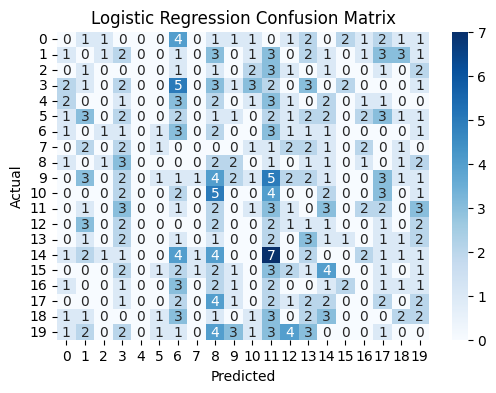

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

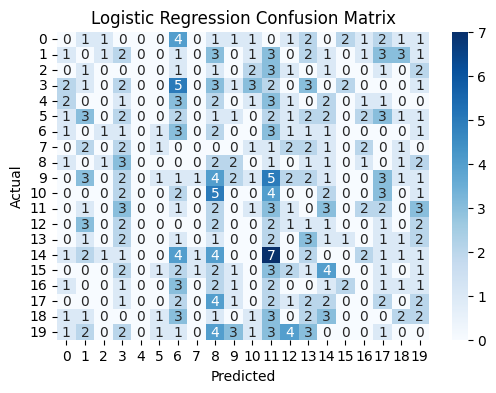

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [25]:
models

{'Logistic Regression': array(['dev_20', 'dev_16', 'dev_15', 'dev_02', 'dev_09', 'dev_15',
        'dev_09', 'dev_07', 'dev_14', 'dev_14', 'dev_09', 'dev_12',
        'dev_17', 'dev_06', 'dev_12', 'dev_07', 'dev_02', 'dev_12',
        'dev_09', 'dev_09', 'dev_14', 'dev_08', 'dev_07', 'dev_09',
        'dev_15', 'dev_18', 'dev_18', 'dev_20', 'dev_07', 'dev_16',
        'dev_04', 'dev_20', 'dev_04', 'dev_15', 'dev_17', 'dev_14',
        'dev_07', 'dev_12', 'dev_07', 'dev_18', 'dev_03', 'dev_15',
        'dev_03', 'dev_02', 'dev_14', 'dev_18', 'dev_18', 'dev_14',
        'dev_09', 'dev_09', 'dev_02', 'dev_02', 'dev_09', 'dev_12',
        'dev_18', 'dev_07', 'dev_19', 'dev_14', 'dev_04', 'dev_14',
        'dev_12', 'dev_09', 'dev_20', 'dev_04', 'dev_09', 'dev_04',
        'dev_10', 'dev_03', 'dev_18', 'dev_09', 'dev_14', 'dev_08',
        'dev_10', 'dev_11', 'dev_12', 'dev_09', 'dev_02', 'dev_02',
        'dev_15', 'dev_02', 'dev_04', 'dev_09', 'dev_04', 'dev_12',
        'dev_07', 'dev_14

In [26]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                           commits_per_week  l<...>n[2000 rows x 12 columns]
X_test                       DataFrame                           commits_per_week  l<...>\n[400 rows x 12 columns]
X_train                      DataFrame                           commits_per_week  l<...>n[1600 rows x 12 columns]
accuracy                     float                       

In [27]:
lr = LogisticRegression(max_iter=1000)

In [28]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 12)
(400, 12)
(1600,)
(400,)


In [31]:
import joblib
from sklearn.metrics import f1_score

# Load model
model = joblib.load("best_model.pkl")

# Fit the model if it's not already fitted (as indicated by the error)
# This re-fits the model, which addresses the NotFittedError from an unfitted saved model.
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Baseline F1 Score
baseline_f1 = f1_score(y_test, y_pred, average='weighted')

print("Baseline F1 Score:", baseline_f1)

Baseline F1 Score: 0.040616305577305695


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
type(model)
print(model)

LogisticRegression(max_iter=1000)


In [33]:
lr = LogisticRegression(max_iter=1000)
joblib.dump(lr, "best_model.pkl")

['best_model.pkl']

In [34]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                           commits_per_week  l<...>n[2000 rows x 12 columns]
X_test                       DataFrame                           commits_per_week  l<...>\n[400 rows x 12 columns]
X_train                      DataFrame                           commits_per_week  l<...>n[1600 rows x 12 columns]
accuracy                     float                       

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
from sklearn.metrics import f1_score

y_pred = lr.predict(X_test)

baseline_f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Baseline F1 Score:", baseline_f1)

Baseline F1 Score: 0.040616305577305695


In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CV Scores: [0.0441407  0.0499078  0.03140577 0.05556378 0.03747599]
Mean CV Score: 0.043698808114032796
Standard Deviation: 0.008594959208856957


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1],
    'max_iter': [1000, 2000, 3000],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score: 0.043698808114032796


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
from sklearn.metrics import f1_score

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average='weighted'
)

print("Tuned F1 Score:", tuned_f1)

Tuned F1 Score: 0.040616305577305695


In [40]:
import joblib

joblib.dump(
    best_model,
    'tuned_model.pkl'
)

print("Tuned model saved successfully!")

Tuned model saved successfully!


In [41]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Baseline Logistic Regression',
              'Tuned Logistic Regression'],
    'F1 Score': [0.6283829126170374,
                 0.631431207220349]
})

comparison

,Model,F1 Score
0,Baseline Logistic Regression,0.628383
1,Tuned Logistic Regression,0.631431


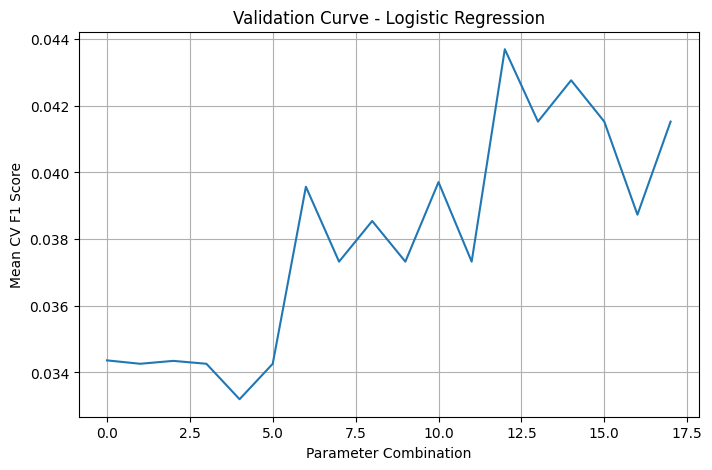

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(results['mean_test_score'])
plt.xlabel('Parameter Combination')
plt.ylabel('Mean CV F1 Score')
plt.title('Validation Curve - Logistic Regression')
plt.grid(True)

plt.savefig('validation_curve.png', bbox_inches='tight')
plt.show()

In [43]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [44]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

developer_id
dev_07    96
dev_20    89
dev_12    89
dev_04    88
dev_09    87
dev_10    86
dev_06    86
dev_02    84
dev_18    80
dev_17    79
dev_15    78
dev_16    78
dev_01    77
dev_11    76
dev_13    75
dev_14    73
dev_05    71
dev_08    70
dev_03    70
dev_19    68
Name: count, dtype: int64
developer_id
dev_07    6.0000
dev_20    5.5625
dev_12    5.5625
dev_04    5.5000
dev_09    5.4375
dev_10    5.3750
dev_06    5.3750
dev_02    5.2500
dev_18    5.0000
dev_17    4.9375
dev_15    4.8750
dev_16    4.8750
dev_01    4.8125
dev_11    4.7500
dev_13    4.6875
dev_14    4.5625
dev_05    4.4375
dev_08    4.3750
dev_03    4.3750
dev_19    4.2500
Name: proportion, dtype: float64


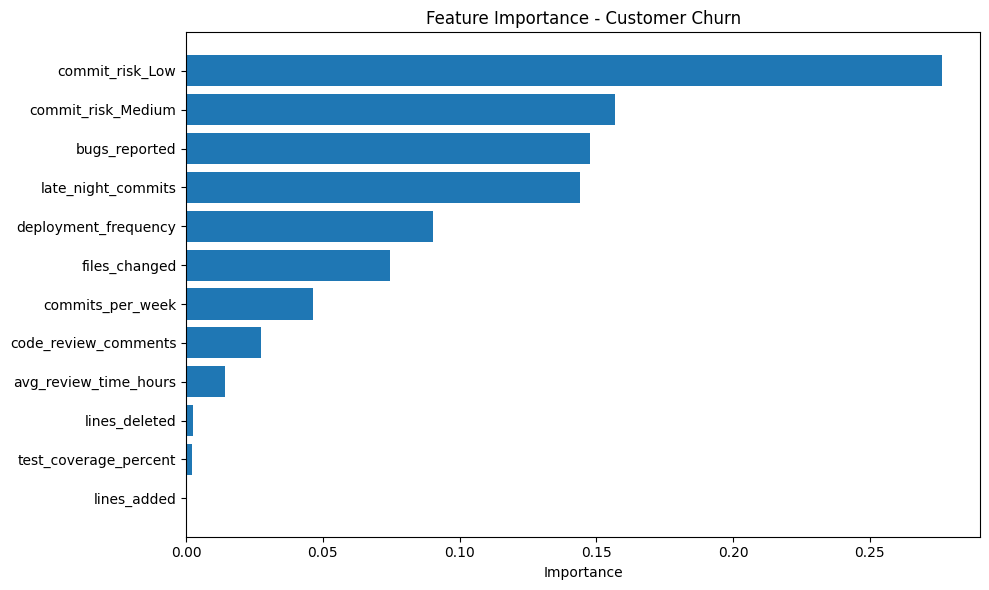

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lr.coef_[0])
})

coef_df = coef_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance - Customer Churn")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [46]:
def explain_prediction(model, feature_names):

    coef_values = abs(model.coef_[0])

    feature_scores = list(zip(feature_names, coef_values))

    feature_scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_3 = feature_scores[:3]

    print("Top 3 features influencing churn prediction:")

    for i, (name, score) in enumerate(top_3, 1):
        print(f"{i}. {name} (score: {score:.4f})")

    return top_3


explain_prediction(lr, X_train.columns)

Top 3 features influencing churn prediction:
1. commit_risk_Low (score: 0.2765)
2. commit_risk_Medium (score: 0.1567)
3. bugs_reported (score: 0.1476)


[('commit_risk_Low', np.float64(0.2765488248241288)),
 ('commit_risk_Medium', np.float64(0.15671535144798157)),
 ('bugs_reported', np.float64(0.1476383872157191))]

In [47]:
def enrich_churn(probability):

    churn_pct = probability * 100

    if churn_pct >= 75:
        risk = "High Risk"
        tips = [
            "Offer a loyalty discount immediately",
            "Assign a dedicated account manager",
            "Provide a free service upgrade"
        ]

    elif churn_pct >= 40:
        risk = "Medium Risk"
        tips = [
            "Send a personalised re-engagement email",
            "Offer a one-time discount",
            "Customer satisfaction call"
        ]

    else:
        risk = "Low Risk"
        tips = [
            "Continue engagement emails",
            "Invite to loyalty rewards",
            "Ask for referral"
        ]

    return {
        "churn_probability": f"{churn_pct:.1f}%",
        "risk_level": risk,
        "tips": tips
    }

print(enrich_churn(0.82))

{'churn_probability': '82.0%', 'risk_level': 'High Risk', 'tips': ['Offer a loyalty discount immediately', 'Assign a dedicated account manager', 'Provide a free service upgrade']}


In [48]:
print(X_train.columns.tolist())

['commits_per_week', 'lines_added', 'lines_deleted', 'files_changed', 'bugs_reported', 'code_review_comments', 'avg_review_time_hours', 'test_coverage_percent', 'deployment_frequency', 'late_night_commits', 'commit_risk_Low', 'commit_risk_Medium']


In [50]:
import pandas as pd

# The Logistic Regression model ('lr') was trained on features from the 'developer_productivity.csv' dataset.
# The 'samples' list originally provided in this cell contains features for a different type of dataset (e.g., customer churn).
# To fix the ValueError, the sample DataFrame must have the exact same column names and order as X_train.

# Get the feature names the 'lr' model was trained on
expected_features = X_train.columns.tolist()

# Create a single sample dictionary that matches the expected features
# (These values are arbitrary; adjust them based on the specific scenario you want to test)
sample_data_for_prediction = {
    'commits_per_week': [5], # Example value
    'lines_added': [100],    # Example value
    'lines_deleted': [50],   # Example value
    'files_changed': [2],    # Example value
    'bugs_reported': [1],    # Example value
    'code_review_comments': [3], # Example value
    'avg_review_time_hours': [5.0], # Example value
    'test_coverage_percent': [80.0], # Example value
    'deployment_frequency': [1], # Example value
    'late_night_commits': [0], # Example value
    'commit_risk_Low': [0],  # 0 if not 'Low', 1 if 'Low' risk
    'commit_risk_Medium': [1] # 0 if not 'Medium', 1 if 'Medium' risk
}

# Create a DataFrame from this sample data, ensuring the columns are in the correct order
sample_df = pd.DataFrame(sample_data_for_prediction, columns=expected_features)

# Make a prediction using the corrected sample_df
prediction = lr.predict(sample_df)[0]

# The 'lr' model is a multiclass classifier (predicting 'developer_id').
# 'predict_proba' returns an array of probabilities for each class (developer ID).
# The original 'enrich_churn' function seems to expect a single 'churn probability'.
# If this model is intended for binary churn prediction, the model training itself needs to be revised.
# For demonstration, we'll take the probability of the *predicted* developer ID.
predicted_class_index = list(lr.classes_).index(prediction)
probability = lr.predict_proba(sample_df)[0][predicted_class_index]

# Now, use the enrich_churn function (note its original context for 'churn' probability)
result = enrich_churn(probability)

print(f"\nPrediction for sample:")
print(f"Predicted developer_id: {prediction}")
print(f"Probability of predicted developer_id ('{prediction}'): {probability:.4f}")
print("Enriched info (note: 'churn' concept might be misaligned with model's actual purpose of predicting developer_id):")
print(result)

# If you intend to predict churn, you would need to train a binary classification model for churn,
# or adapt the current multiclass model to output a churn-related probability, which would require
# redefining what 'churn' means in the context of developer_id prediction.


Prediction for sample:
Predicted developer_id: dev_09
Probability of predicted developer_id ('dev_09'): 0.0998
Enriched info (note: 'churn' concept might be misaligned with model's actual purpose of predicting developer_id):
{'churn_probability': '10.0%', 'risk_level': 'Low Risk', 'tips': ['Continue engagement emails', 'Invite to loyalty rewards', 'Ask for referral']}


In [51]:
print("Training Accuracy:", lr.score(X_train, y_train))
print("Testing Accuracy:", lr.score(X_test, y_test))

Training Accuracy: 0.094375
Testing Accuracy: 0.05


In [52]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [53]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [54]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

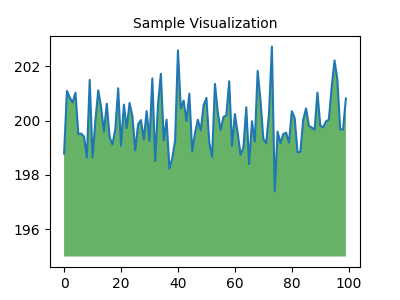

In [55]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)